# Exercise 1: PCA

For this exercise, we will be using the wine dataset from https://archive.ics.uci.edu/dataset/109/wine.

Perform a principle component analysis using the manual method on the dataset.

## Task 1 - Data Exploration
- Load the dataset and perform basic data exploration.
- Clean the dataset if necessary.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# Read the dataset
features = ['Class', 'Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash', 'Magnesium', 'Total phenols',
           'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins', 'Color intensity', 'Hue', 'OD280/OD315', 'Proline']
df = pd.read_csv('wine/wine.data', header=1, names=features)
df.head()

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315,Proline
0,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
1,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
2,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
3,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
4,1,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290


In [3]:
df.shape

(176, 14)

In [4]:
df.isnull().sum()

Class                   0
Alcohol                 0
Malic acid              0
Ash                     0
Alcalinity of ash       0
Magnesium               0
Total phenols           0
Flavanoids              0
Nonflavanoid phenols    0
Proanthocyanins         0
Color intensity         0
Hue                     0
OD280/OD315             0
Proline                 0
dtype: int64

In [5]:
df.describe()

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315,Proline
count,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000
mean,1.948864,12.992500,2.343068,2.367443,19.564205,99.585227,2.290227,2.019261,0.362898,1.588693,5.058636,0.956455,2.599773,743.363636
std,0.772897,0.810965,1.121705,0.275332,3.285644,14.214424,0.627667,0.999949,0.124768,0.572703,2.330517,0.229681,0.704537,314.935374
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.355000,1.597500,2.210000,17.200000,88.000000,1.735000,1.175000,0.270000,1.247500,3.200000,0.780000,1.927500,500.000000
50%,2.000000,13.050000,1.870000,2.360000,19.500000,98.000000,2.335000,2.120000,0.340000,1.555000,4.690000,0.960000,2.780000,666.000000
75%,3.000000,13.672500,3.105000,2.560000,21.500000,107.000000,2.800000,2.865000,0.442500,1.950000,6.212500,1.120000,3.170000,973.750000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


## Task 2 - Data Visualization
- Perform some basic data visualization on the dataset to gain more insight on the dataset.

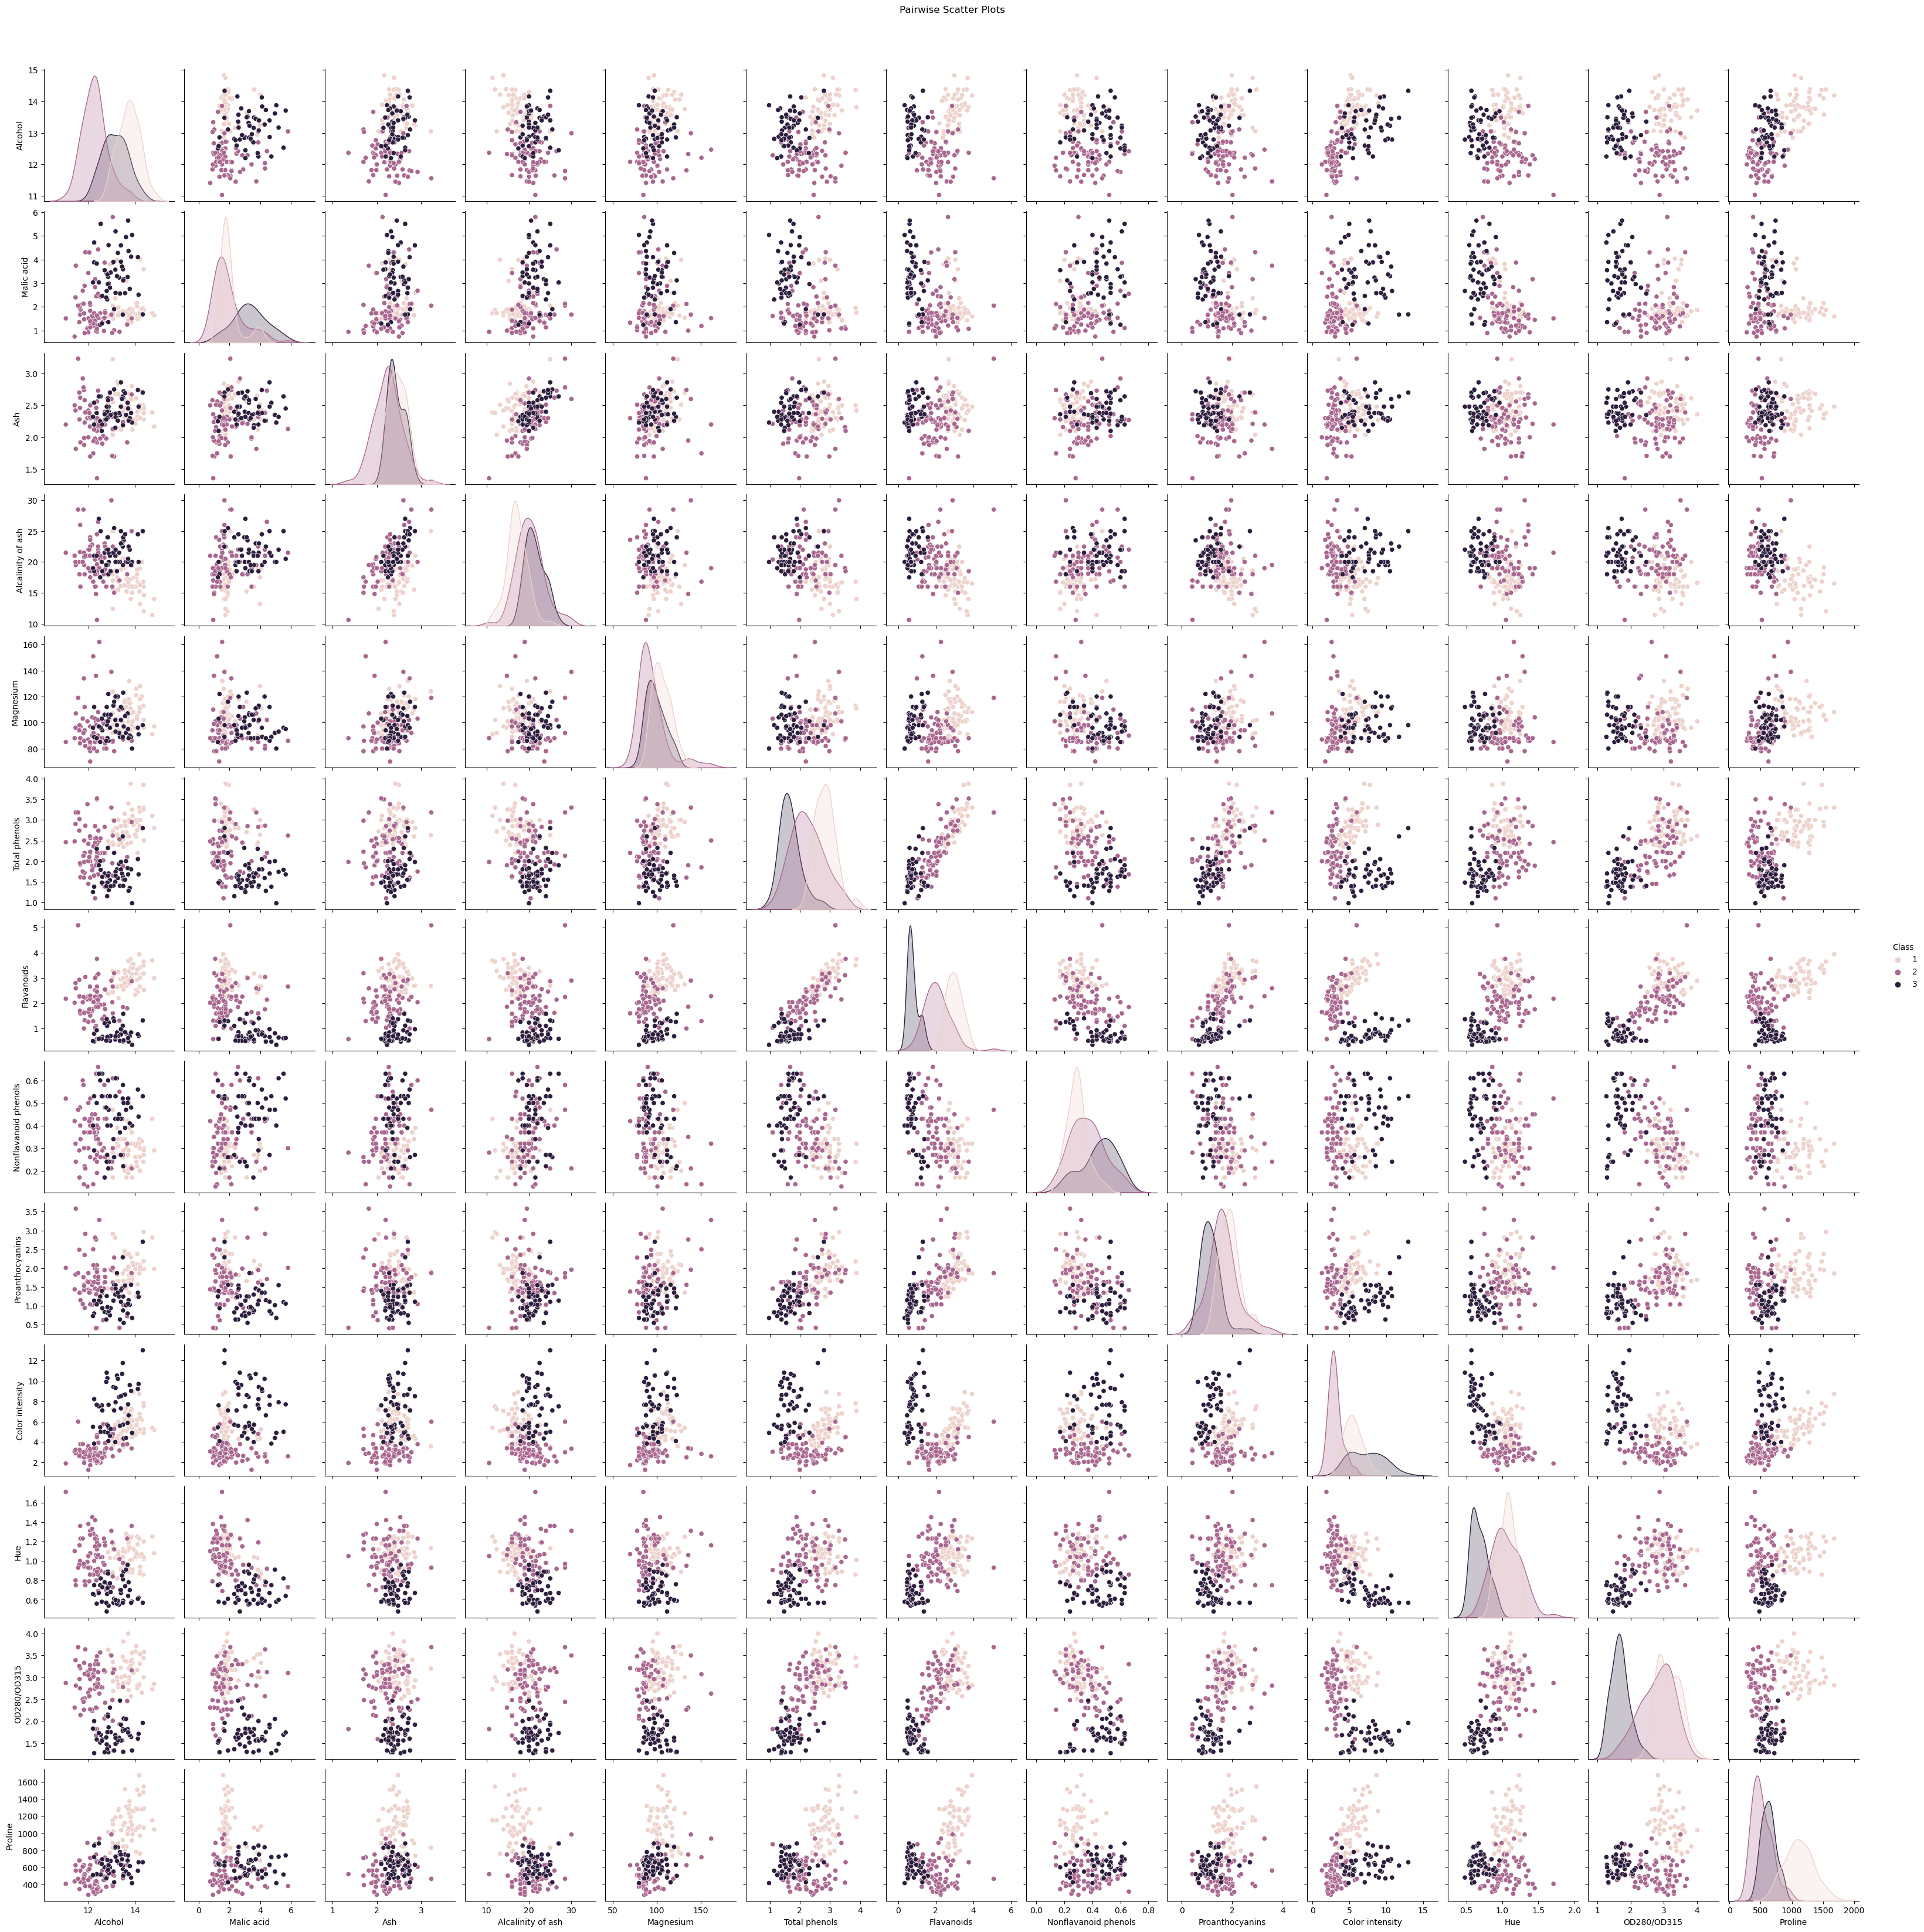

In [6]:
# Pairwise Scatter Plots of the first 5 principal components
sns.pairplot(df, hue="Class", diag_kind='kde')
plt.suptitle("Pairwise Scatter Plots", y=1.02)
plt.show()

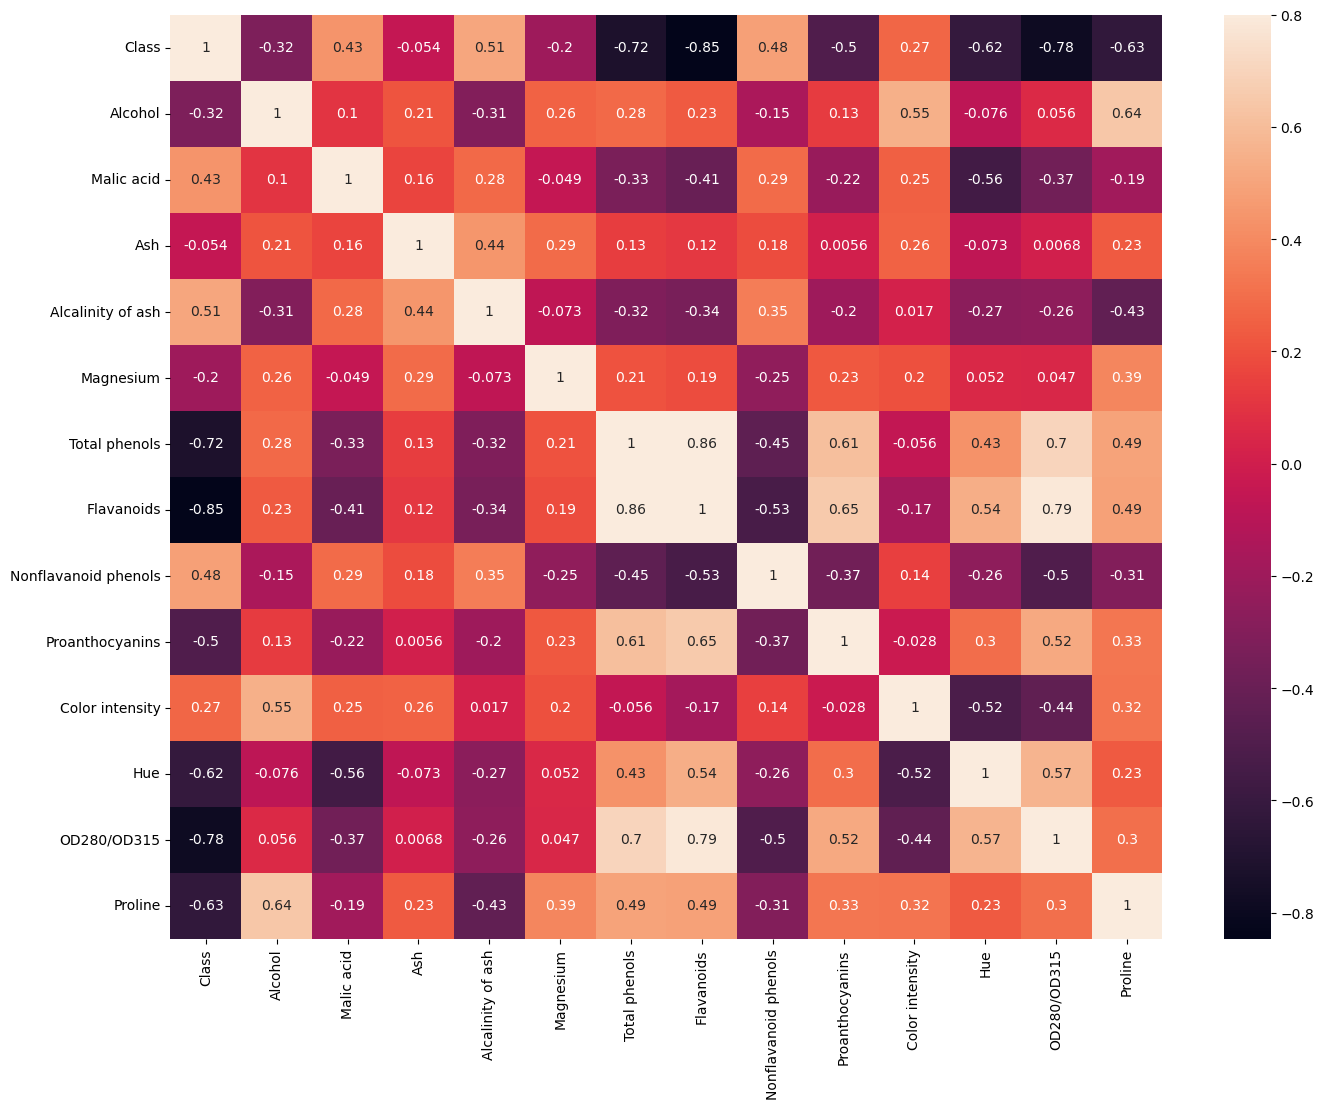

In [7]:
corrmat = df.corr()
fig = plt.figure(figsize = (16, 12))

sns.heatmap(corrmat, vmax = 0.8, annot=True)
plt.show()

In [8]:
X = df.drop(['Class'], axis=1)
X.head()

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315,Proline
0,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
2,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
3,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
4,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290


In [9]:
y = df['Class']
y.head()

0    1
1    1
2    1
3    1
4    1
Name: Class, dtype: int64

In [10]:
df['Class'].value_counts()

Class
2    71
1    57
3    48
Name: count, dtype: int64

## Task 3 - Standardize the Data
- Scale the dataset.

In [11]:
# scale the dataset
X_scaled = StandardScaler().fit_transform(X)
X_scaled[:5]

array([[ 0.20713329,  0.01513778,  1.10201514, -0.29429713,  0.09981475,
         0.81448806,  1.22428374, -0.50555688,  2.13861564,  0.26738122,
         0.32112114,  0.81167362,  1.40630879],
       [ 1.70343942, -0.35142   ,  0.48281715, -0.84369801,  0.94643627,
         2.49212285,  1.47500976, -0.98782252,  1.03543024,  1.17964602,
        -0.42114898,  1.21023157,  2.34568137],
       [ 0.30606262,  0.22076775,  1.83048337,  0.43823739,  1.29919524,
         0.81448806,  0.67268651,  0.21784158,  0.40503858, -0.31784526,
         0.36478408,  0.47005252, -0.02663244],
       [ 1.49321459, -0.52128823,  0.30070009, -1.33205436,  0.87588448,
         1.56542934,  1.37471935, -0.18404645,  0.66770177,  0.72781675,
         0.40844703,  0.35617882,  2.25015196],
       [ 1.72817175, -0.42294347,  0.30070009, -1.51518798, -0.25294421,
         0.33516383,  0.50219282, -0.50555688,  0.68521265,  0.08234637,
         0.27745819,  1.39527633,  1.74066174]])

## Task 4 - Apply PCA

In [48]:
# Calculate the PCA manually without the scikit-learn library.

In [54]:
df.shape

(176, 14)

In [13]:
# get covariance matrix
features = X_scaled.T
cov_matrix = np.cov(features)
cov_matrix[:5]

array([[ 1.00571429,  0.10135881,  0.21382821, -0.30698503,  0.26022722,
         0.28565115,  0.23076884, -0.1514274 ,  0.12920748,  0.55167469,
        -0.07645103,  0.05630612,  0.64516154],
       [ 0.10135881,  1.00571429,  0.1639683 ,  0.28594066, -0.04928103,
        -0.33432651, -0.4104745 ,  0.29157669, -0.22110461,  0.25088721,
        -0.56356013, -0.3671712 , -0.18845105],
       [ 0.21382821,  0.1639683 ,  1.00571429,  0.44631571,  0.28944541,
         0.13198394,  0.1186336 ,  0.18526088,  0.00560584,  0.25931282,
        -0.07387014,  0.0068821 ,  0.2298883 ],
       [-0.30698503,  0.28594066,  0.44631571,  1.00571429, -0.07300805,
        -0.31718973, -0.34504732,  0.3567565 , -0.20337182,  0.01673997,
        -0.27348779, -0.25912076, -0.43440939],
       [ 0.26022722, -0.04928103,  0.28944541, -0.07300805,  1.00571429,
         0.20949043,  0.18834057, -0.25388414,  0.22807663,  0.20057333,
         0.05229664,  0.04721315,  0.390643  ]])

In [50]:
cov_matrix

array([[ 1.00571429,  0.10135881,  0.21382821, -0.30698503,  0.26022722,
         0.28565115,  0.23076884, -0.1514274 ,  0.12920748,  0.55167469,
        -0.07645103,  0.05630612,  0.64516154],
       [ 0.10135881,  1.00571429,  0.1639683 ,  0.28594066, -0.04928103,
        -0.33432651, -0.4104745 ,  0.29157669, -0.22110461,  0.25088721,
        -0.56356013, -0.3671712 , -0.18845105],
       [ 0.21382821,  0.1639683 ,  1.00571429,  0.44631571,  0.28944541,
         0.13198394,  0.1186336 ,  0.18526088,  0.00560584,  0.25931282,
        -0.07387014,  0.0068821 ,  0.2298883 ],
       [-0.30698503,  0.28594066,  0.44631571,  1.00571429, -0.07300805,
        -0.31718973, -0.34504732,  0.3567565 , -0.20337182,  0.01673997,
        -0.27348779, -0.25912076, -0.43440939],
       [ 0.26022722, -0.04928103,  0.28944541, -0.07300805,  1.00571429,
         0.20949043,  0.18834057, -0.25388414,  0.22807663,  0.20057333,
         0.05229664,  0.04721315,  0.390643  ],
       [ 0.28565115, -0.334326

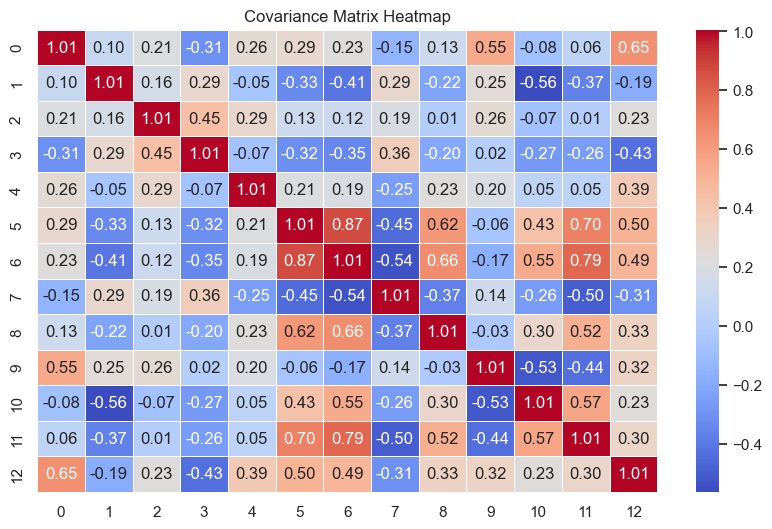

In [52]:
plt.figure(figsize=(10, 6))  # Set figure size
sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Covariance Matrix Heatmap")
plt.show()

In [14]:
# eigen decomposition cov matrix into eigenvectors and eigenvalues
#Eigenvalues represent the importance of each principal component, 
#while eigenvectors define the direction of these components.
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [55]:
eigenvalues

array([4.69974333, 2.5194393 , 1.46081613, 0.93105373, 0.86770755,
       0.64500795, 0.55794231, 0.34933255, 0.29145966, 0.24902375,
       0.22894214, 0.16893891, 0.1048784 ])

In [56]:
eigenvectors

array([[-1.38066134e-01, -4.85674583e-01,  2.06608767e-01,
         2.30824515e-03, -2.69628529e-01,  2.23703580e-01,
         6.25908427e-02,  3.84174513e-01, -4.94367658e-01,
         1.99915261e-01, -2.86241680e-01, -2.48258884e-01,
        -1.35151412e-02],
       [ 2.45680352e-01, -2.21850773e-01, -9.27445925e-02,
        -5.36528469e-01,  6.25949450e-02,  5.25448039e-01,
        -4.36158958e-01,  5.89524823e-02,  5.18958683e-02,
        -2.95552424e-01,  1.31051977e-01,  1.10962507e-01,
        -2.65240677e-02],
       [ 1.54451312e-03, -3.14204671e-01, -6.26369156e-01,
         2.02810392e-01, -1.55303029e-01,  1.46506115e-01,
         1.37033286e-01, -1.73707353e-01,  3.23103971e-01,
        -1.27317999e-01, -4.80930121e-01, -3.82486256e-02,
         1.41083094e-01],
       [ 2.35615515e-01,  1.46626996e-02, -6.15579545e-01,
        -5.88547705e-02,  6.68953102e-02, -9.33706584e-02,
         2.92639538e-01,  4.31377783e-01, -2.11531833e-01,
         1.28674917e-01,  4.49224788e

In [57]:
# Sort eigenvalues and corresponding eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

In [58]:
explained_variances = []
for i in range(len(eigenvalues)):
    explained_variances.append(eigenvalues[i] / np.sum(eigenvalues))

print(np.sum(explained_variances), '\n\n',explained_variances)

1.0 

 [0.3594646342726059, 0.19270186974899906, 0.11173200274666541, 0.0712125889375449, 0.06636749198517782, 0.0493340873467831, 0.04267478302203398, 0.026719054226338728, 0.022292587492326404, 0.019046833774634207, 0.01751087139740416, 0.012921464138128934, 0.008021730911357449]


### Question
- How many principal components above made up more than 70% of the variance in the data?

**Answer:**

In [19]:
4

4

In [60]:
0.3594646342726059+0.19270186974899906+0.11173200274666541+0.0712125889375449+0.06636749198517782

0.801478587690993

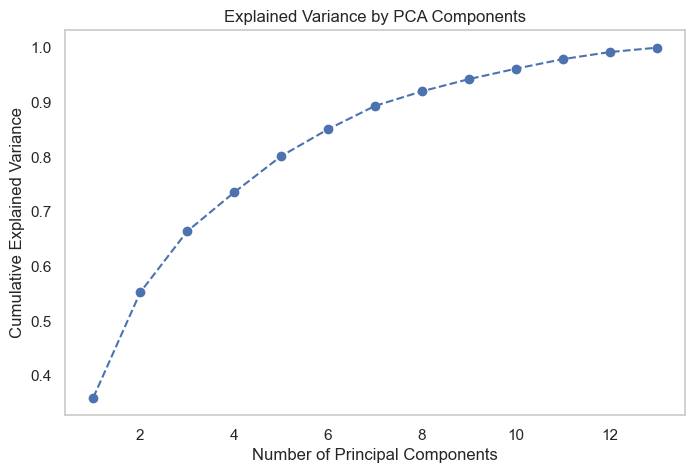

In [49]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)  # Normalize eigenvalues
cumulative_variance = np.cumsum(explained_variance_ratio)  # Compute cumulative variance

# Plot explained variance to find "elbow point"
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker="o", linestyle="--", color="b")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.grid()
plt.show()


In [21]:
### Build PCA using sklearn library

In [22]:
from sklearn.decomposition import PCA

In [62]:
X.shape[1]

13

In [23]:
# We initialize PCA and fit it to the standardized data.
pca = PCA(n_components=X.shape[1])  # Use all features initially
X_pca = pca.fit_transform(X_scaled)  # Apply PCA

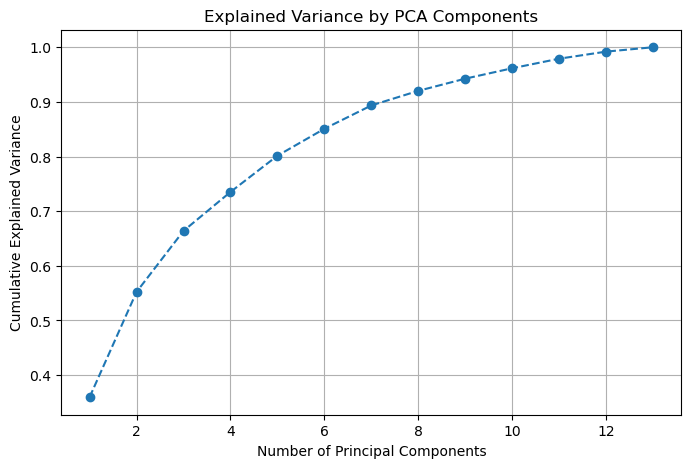

In [24]:
#The explained variance tells how much information each principal component retains.
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot the explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o", linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.grid()
plt.show()


In [25]:
# Select the Optimal Number of Components
#If we see that 5 components explain ~80% of variance, we reduce dimensionality to 5 PCs:

pca = PCA(n_components=5)  # Reduce to 5 principal components
X_PCA = pca.fit_transform(X_scaled)

In [26]:
pca_loadings = pd.DataFrame(pca.components_, columns=X.columns, index=[f"PC{i+1}" for i in range(5)])
print(pca_loadings)

      Alcohol  Malic acid       Ash  Alcalinity of ash  Magnesium  \
PC1  0.138066   -0.245680 -0.001545          -0.235616   0.135713   
PC2 -0.485675   -0.221851 -0.314205           0.014663  -0.299307   
PC3 -0.206609    0.092745  0.626369           0.615580   0.134824   
PC4 -0.002308    0.536528 -0.202810           0.058855  -0.387284   
PC5 -0.269629    0.062595 -0.155303           0.066895   0.708065   

     Total phenols  Flavanoids  Nonflavanoid phenols  Proanthocyanins  \
PC1       0.396217    0.424622             -0.298338         0.316006   
PC2      -0.069228   -0.000429             -0.025082        -0.039348   
PC3       0.143277    0.148727              0.168485         0.136840   
PC4       0.201999    0.155423             -0.178038         0.388383   
PC5      -0.133947   -0.098217             -0.511942         0.155899   

     Color intensity       Hue  OD280/OD315   Proline  
PC1        -0.092294  0.299309     0.376710  0.283677  
PC2        -0.528023  0.274693    

### Visualizations

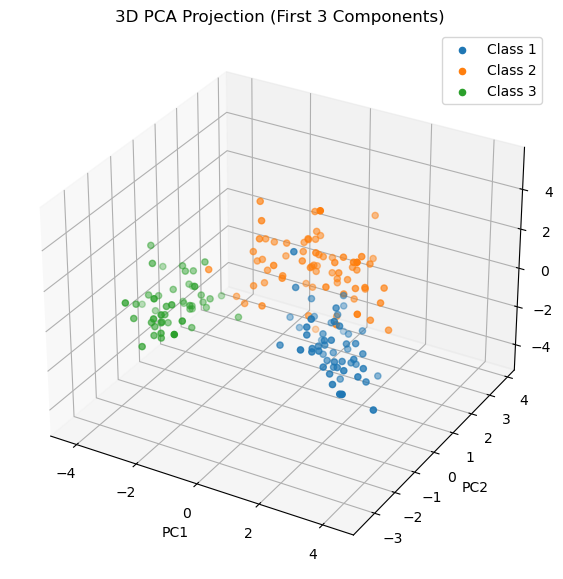

In [27]:
# 3D Scatter Plot using the first 3 principal components
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for label in np.unique(y):
    ax.scatter(X_PCA[y == label, 0], X_PCA[y == label, 1], X_PCA[y == label, 2], label=f'Class {label}')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA Projection (First 3 Components)')
ax.legend()
plt.show()

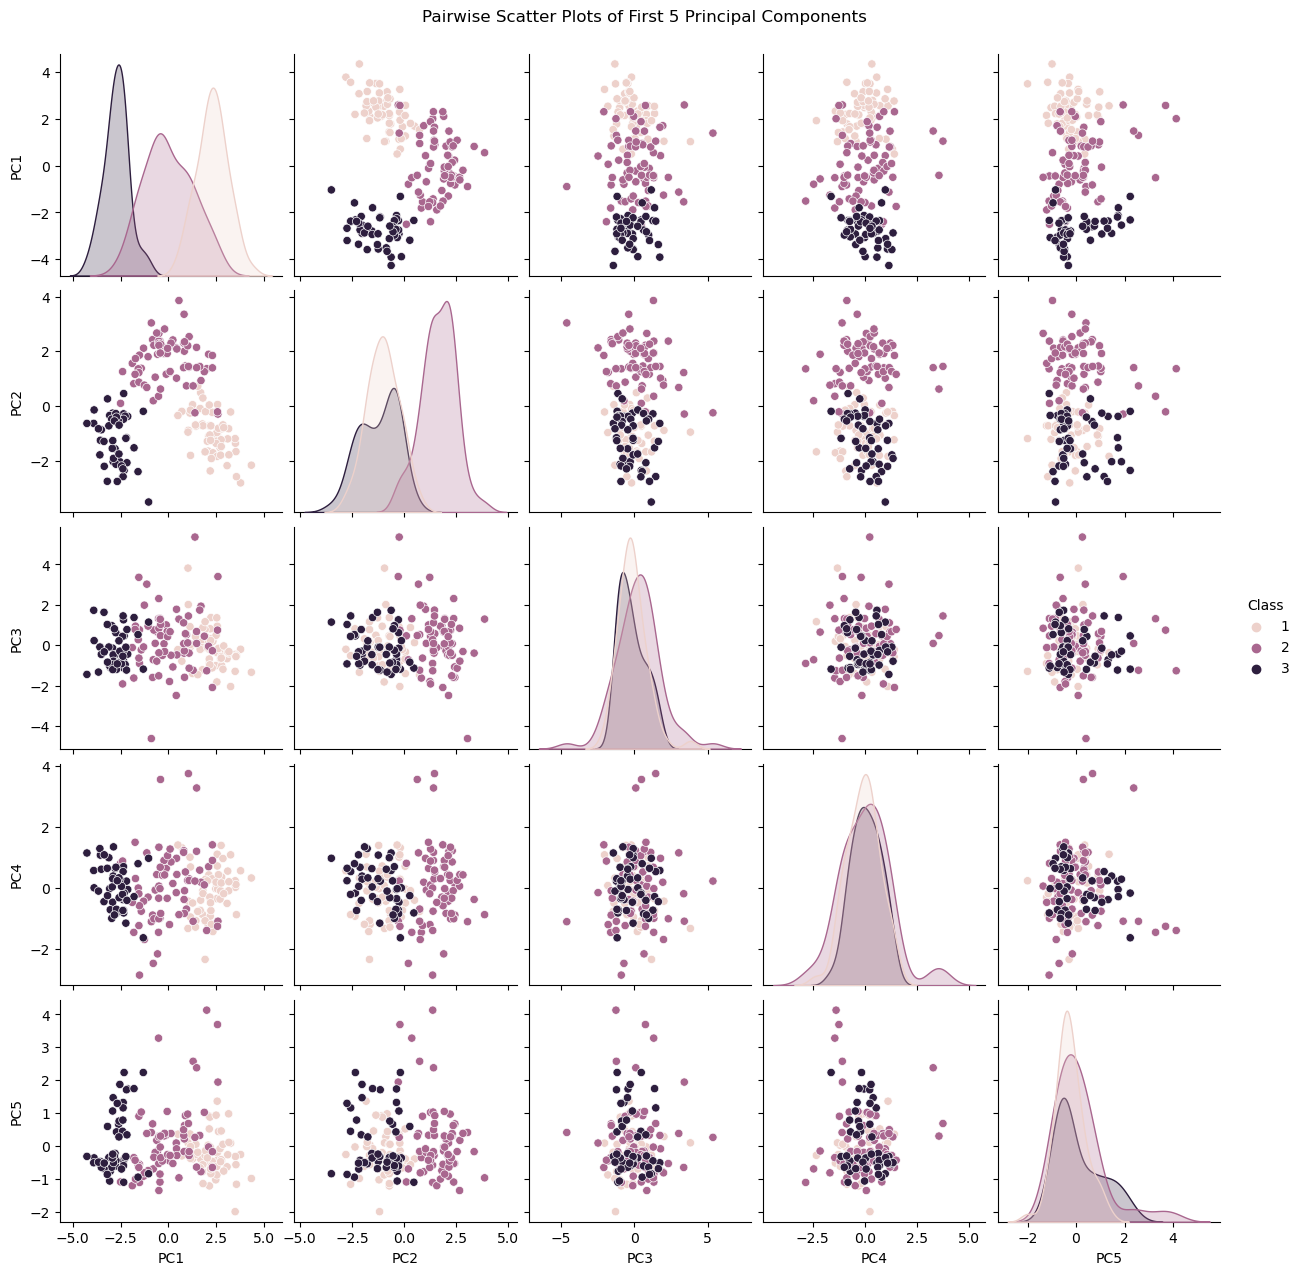

In [28]:
# Pairwise Scatter Plots of the first 5 principal components
import seaborn as sns
pca_df = pd.DataFrame(X_PCA, columns=[f'PC{i+1}' for i in range(5)])
pca_df['Class'] = y

sns.pairplot(pca_df, hue="Class", diag_kind='kde')
plt.suptitle("Pairwise Scatter Plots of First 5 Principal Components", y=1.02)
plt.show()

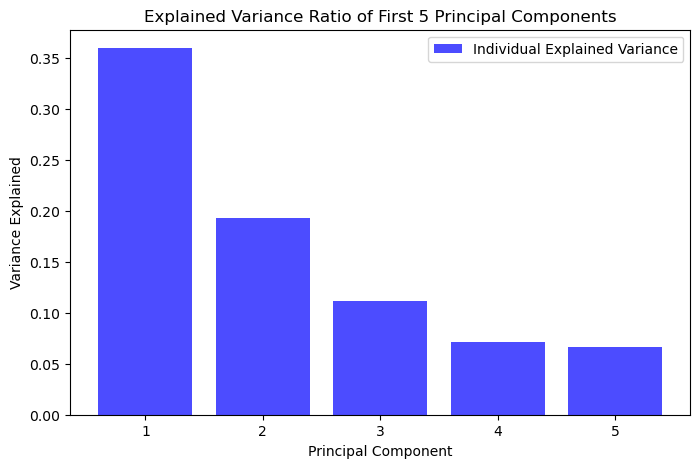

In [29]:
# Explained variance ratio plot
plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), pca.explained_variance_ratio_, alpha=0.7, color='blue', label='Individual Explained Variance')
plt.ylabel('Variance Explained')
plt.xlabel('Principal Component')
plt.title('Explained Variance Ratio of First 5 Principal Components')
plt.legend()
plt.show()

In [63]:
### Create new DataFrame with 5 Principal Components
df.head()

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315,Proline
0,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
1,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
2,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
3,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
4,1,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290


In [31]:
X_PCA_DF = pd.DataFrame(data = X_PCA, columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])

In [32]:
X_PCA_DF.head()

,PC1,PC2,PC3,PC4,PC5
0,2.551417,-1.051399,0.942700,0.728104,-0.205312
1,3.770055,-2.791594,-0.197404,0.571849,-0.261906
2,1.037646,-0.876937,2.013870,-0.422777,0.283068
3,3.063952,-2.162787,-0.663838,-0.496724,-0.635405
4,2.472963,-1.203593,-1.007559,-0.013911,-1.031994


In [33]:
PCA_finalDf = pd.concat([X_PCA_DF, y], axis = 1)
PCA_finalDf.head()

,PC1,PC2,PC3,PC4,PC5,Class
0,2.551417,-1.051399,0.942700,0.728104,-0.205312,1
1,3.770055,-2.791594,-0.197404,0.571849,-0.261906,1
2,1.037646,-0.876937,2.013870,-0.422777,0.283068,1
3,3.063952,-2.162787,-0.663838,-0.496724,-0.635405,1
4,2.472963,-1.203593,-1.007559,-0.013911,-1.031994,1


In [34]:
# Import train_test_split function
from sklearn.model_selection import train_test_split

X_PCA=PCA_finalDf[['PC1', 'PC2', 'PC3', 'PC4', 'PC5']]  # Features
y_PCA=PCA_finalDf['Class']  # Labels

In [35]:
# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X_PCA, y_PCA, test_size=0.3) # 70% training a

### Build Decision Tree Classifier Model

In [36]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(max_depth=2, random_state=0)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=0)

In [37]:
# Predicting the Train set results
y_train_pred = classifier.predict(X_train)

In [38]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

cm = confusion_matrix(y_train, y_train_pred)
print(cm)
print("Accuracy:",accuracy_score(y_train, y_train_pred))

[[41  0  0]
 [ 4 45  0]
 [ 0  0 33]]
Accuracy: 0.967479674796748


In [39]:
# Predicting the Test set results
y_test_pred = classifier.predict(X_test)

In [40]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

cm = confusion_matrix(y_test, y_test_pred)
print(cm)
print("Accuracy:",accuracy_score(y_test, y_test_pred))

[[15  1  0]
 [ 1 20  1]
 [ 0  0 15]]
Accuracy: 0.9433962264150944


### Build K-means Clustering Model

In [41]:
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import os
os.environ["OMP_NUM_THREADS"] = "1"

# Set visualization style
sns.set(style="whitegrid")

C:\Users\Priyanka\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Priyanka\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Priyanka\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Priyanka\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory le

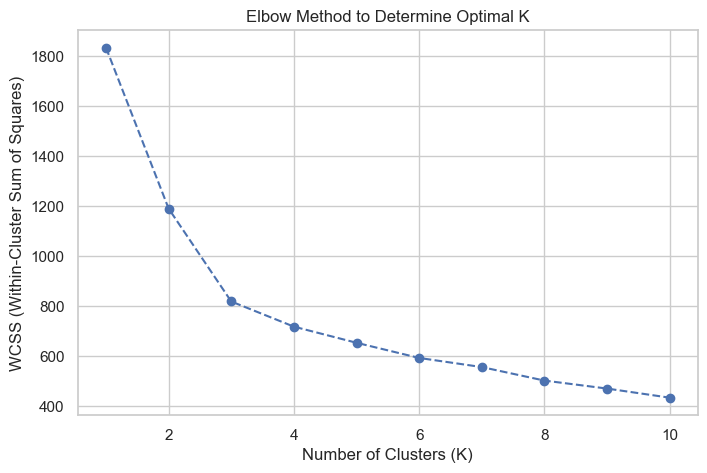

In [42]:
wcss = []  # Within-cluster sum of squares

for k in range(1, 11):  # Checking k from 1 to 10
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_PCA)
    wcss.append(kmeans.inertia_)  # Inertia = WCSS

# Plot the Elbow curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.title("Elbow Method to Determine Optimal K")
plt.show()


In [43]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_PCA)  # Assign clusters

# Add cluster labels to the dataset
PCA_finalDf['Cluster'] = y_kmeans

# Print cluster centers
print("Cluster Centers:\n", kmeans.cluster_centers_)

C:\Users\Priyanka\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Cluster Centers:
 [[ 0.00910219  1.76460407  0.16686268  0.07125574  0.07278191]
 [ 2.28475632 -0.97135597  0.01466634 -0.13031692 -0.14344257]
 [-2.69954945 -1.10623346 -0.22992264  0.06249788  0.0759947 ]]


In [68]:
PCA_finalDf.tail()

,PC1,PC2,PC3,PC4,PC5,Class,Cluster
171,-3.353787,-2.187415,-0.325802,1.093185,-0.523473,3,2
172,-2.585569,-1.738083,0.220565,0.339176,0.273567,3,2
173,-2.673548,-2.738903,-0.922438,0.245827,1.295144,3,2
174,-2.379735,-2.279062,-0.543270,-0.729216,0.786143,3,2
175,-3.195124,-2.734046,1.030171,0.652713,-0.867498,3,2


In [44]:
silhouette_avg = silhouette_score(X_PCA, y_kmeans)
print(f"Silhouette Score: {silhouette_avg:.4f}")

Silhouette Score: 0.3679


### Visualize the Clusters

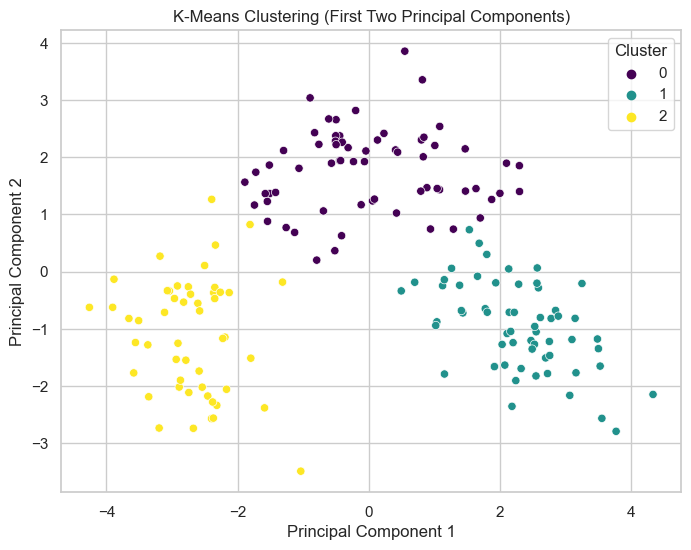

In [45]:
#2D Plot of the First Two Principal Components
plt.figure(figsize=(8, 6))
sns.scatterplot(x=PCA_finalDf["PC1"], y=PCA_finalDf["PC2"], hue=PCA_finalDf["Cluster"], palette="viridis")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering (First Two Principal Components)")
plt.legend(title="Cluster")
plt.show()

In [46]:
#3D Plot (First 3 Principal Components)

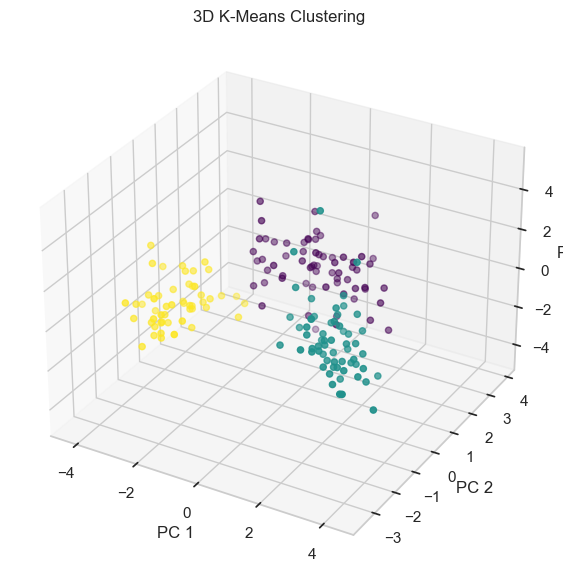

In [47]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(PCA_finalDf["PC1"], PCA_finalDf["PC2"], PCA_finalDf["PC3"], c=PCA_finalDf["Cluster"], cmap="viridis")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")
ax.set_title("3D K-Means Clustering")
plt.show()
